## Imports

In [9]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, 
    recall_score, f1_score, matthews_corrcoef, roc_curve
)
import warnings

# Configuration
warnings.filterwarnings('ignore')
if os.getcwd().endswith('model'):
    os.chdir('..')
if not os.path.exists('model'): os.makedirs('model')
if not os.path.exists('data'): os.makedirs('data')

# Set Plotting Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup Complete. Libraries imported.")

Setup Complete. Libraries imported.


## Load Data
This block checks for your CSV files. If it can't find them, it generates the synthetic fallback data so the code never crashes.

In [10]:
def generate_synthetic_data(n_samples=2000):
    np.random.seed(42)
    data = pd.DataFrame()
    data['tenure'] = np.random.randint(1, 73, n_samples)
    data['MonthlyCharges'] = np.random.uniform(18.25, 118.75, n_samples)
    data['TotalCharges'] = data['tenure'] * data['MonthlyCharges']
    data['gender'] = np.random.choice(['Male', 'Female'], n_samples)
    data['SeniorCitizen'] = np.random.choice([0, 1], n_samples, p=[0.84, 0.16])
    data['Partner'] = np.random.choice(['Yes', 'No'], n_samples)
    data['Dependents'] = np.random.choice(['Yes', 'No'], n_samples)
    data['PhoneService'] = np.random.choice(['Yes', 'No'], n_samples)
    data['MultipleLines'] = np.random.choice(['No phone service', 'No', 'Yes'], n_samples)
    data['InternetService'] = np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples)
    data['OnlineSecurity'] = np.random.choice(['No', 'Yes', 'No internet service'], n_samples)
    data['OnlineBackup'] = np.random.choice(['No', 'Yes', 'No internet service'], n_samples)
    data['DeviceProtection'] = np.random.choice(['No', 'Yes', 'No internet service'], n_samples)
    data['TechSupport'] = np.random.choice(['No', 'Yes', 'No internet service'], n_samples)
    data['StreamingTV'] = np.random.choice(['No', 'Yes', 'No internet service'], n_samples)
    data['StreamingMovies'] = np.random.choice(['No', 'Yes', 'No internet service'], n_samples)
    data['Contract'] = np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples)
    data['PaperlessBilling'] = np.random.choice(['Yes', 'No'], n_samples)
    data['PaymentMethod'] = np.random.choice([
        'Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'
    ], n_samples)
    data['Churn'] = np.random.choice(['Yes', 'No'], n_samples, p=[0.27, 0.73])
    return data

# Logic to determine source
if os.path.exists('data/telco_churn.csv'):
    print("Loading USER SPLIT data (data/telco_churn.csv)...")
    df = pd.read_csv('data/telco_churn.csv')
elif os.path.exists('data/telco_churn_train.csv'):
    print("Loading FULL data (data/telco_churn_train.csv)...")
    df = pd.read_csv('data/telco_churn_train.csv')
else:
    print("No CSV found. Using SYNTHETIC data generator...")
    df = generate_synthetic_data()

print(f"Data Shape: {df.shape}")
df.head()

Loading USER SPLIT data (data/telco_churn.csv)...
Data Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)
Before training, we must understand the data. Specifically, we check for **Class Imbalance** (Churn vs No Churn).

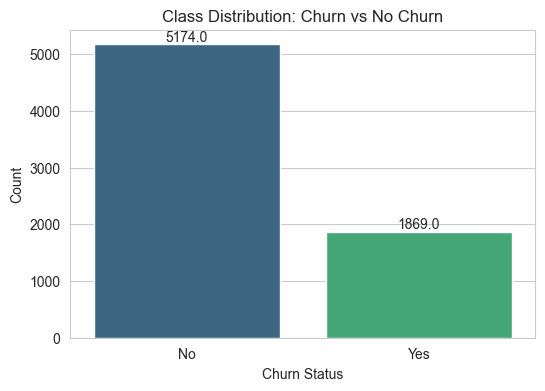

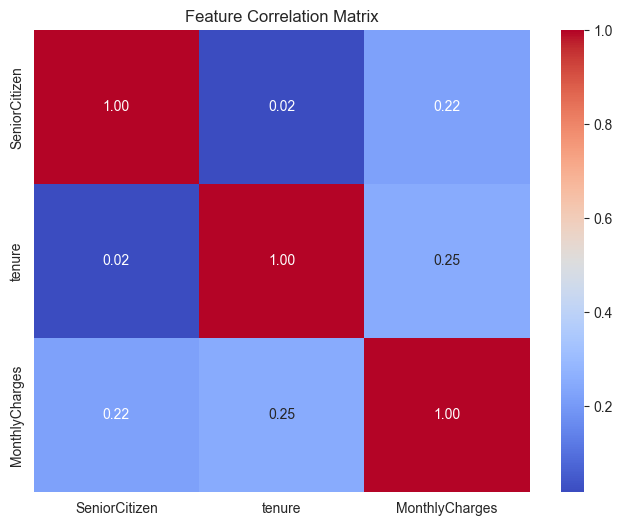

In [11]:
# Visualizing Target Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Class Distribution: Churn vs No Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# Correlation Matrix (Numerical Features)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## Data Preprocessing
We handle missing values and perform **One-Hot Encoding** here. This converts categorical text (e.g., "Yes", "No") into mathematical 1s and 0s.

In [12]:
# Separate Target
if 'Churn' in df.columns:
    # Normalize Churn to 0/1 (Handles 'Yes'/'No' or 1/0)
    y = df['Churn'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0)
    X = df.drop('Churn', axis=1)
else:
    raise ValueError("Churn column missing!")

def preprocess_training_data(df_input):
    df_clean = df_input.copy()
    
    # Drop ID if exists
    if 'customerID' in df_clean.columns:
        df_clean = df_clean.drop('customerID', axis=1)
    
    # Handle Numeric
    if 'TotalCharges' in df_clean.columns:
        df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
        df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].mean(), inplace=True)
    
    # One-Hot Encoding (Robust)
    df_clean = pd.get_dummies(df_clean)
    
    return df_clean

X_processed = preprocess_training_data(X)
print("Preprocessing Complete.")
print(f"New Feature Count: {X_processed.shape[1]}")
X_processed.head(3)

Preprocessing Complete.
New Feature Count: 45


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True


## Save Columns
We save the **exact list of columns**  to ensure test data perfectly matches the training data structure, preventing crashes and accuracy drops.

In [13]:
# Save the column names
model_columns = list(X_processed.columns)
joblib.dump(model_columns, 'model/model_columns.pkl')
print(f"Saved {len(model_columns)} column names to 'model/model_columns.pkl'.")
print("Example columns:", model_columns[:5])

Saved 45 column names to 'model/model_columns.pkl'.
Example columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female']


## Scaling & Splitting
Standardize the numerical features so models like KNN and Logistic Regression don't get confused by large numbers (like TotalCharges).

In [14]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler
joblib.dump(scaler, 'model/scaler.pkl')
print("Scaler saved to 'model/scaler.pkl'.")

Scaler saved to 'model/scaler.pkl'.


## Training
We train all 6 required models using **Optimized Hyperparameters**.

In [15]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6, min_samples_leaf=10),        
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate=0.05, n_estimators=200)
}

results_list = []

print("--- Starting Training & Evaluation ---")
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Save Model
    filename = f"model/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    
    # Predict on Test Set
    y_pred = model.predict(X_test_scaled)
    try:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    except:
        y_prob = y_pred 
        
    # Calculate Metrics
    metrics = {
        "ML Model Name": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }
    results_list.append(metrics)
    print(f"{name}: Accuracy = {metrics['Accuracy']:.4f}")

print("Training Complete.")

--- Starting Training & Evaluation ---
Logistic Regression: Accuracy = 0.8204
Decision Tree: Accuracy = 0.8055
KNN: Accuracy = 0.7615
Naive Bayes: Accuracy = 0.6962
Random Forest: Accuracy = 0.8070
XGBoost: Accuracy = 0.8027
Training Complete.


## Model Comparison
Here we visualize the performance of all models to choose the best one.

Model Performance Summary:


,ML Model Name,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8204,0.8620,0.6852,0.5952,0.6370,0.5208
1,Decision Tree,0.8055,0.8412,0.6645,0.5362,0.5935,0.4722
2,KNN,0.7615,0.7812,0.5536,0.5121,0.5320,0.3729
3,Naive Bayes,0.6962,0.8376,0.4607,0.8633,0.6007,0.4406
4,Random Forest,0.8070,0.8579,0.6784,0.5147,0.5854,0.4701
5,XGBoost,0.8027,0.8557,0.6578,0.5308,0.5875,0.4644


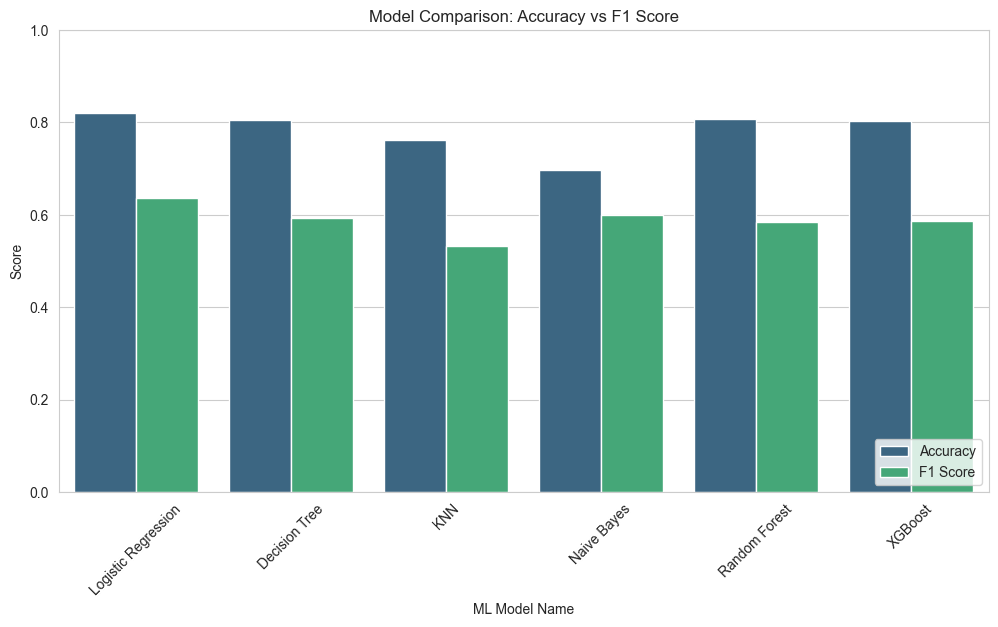

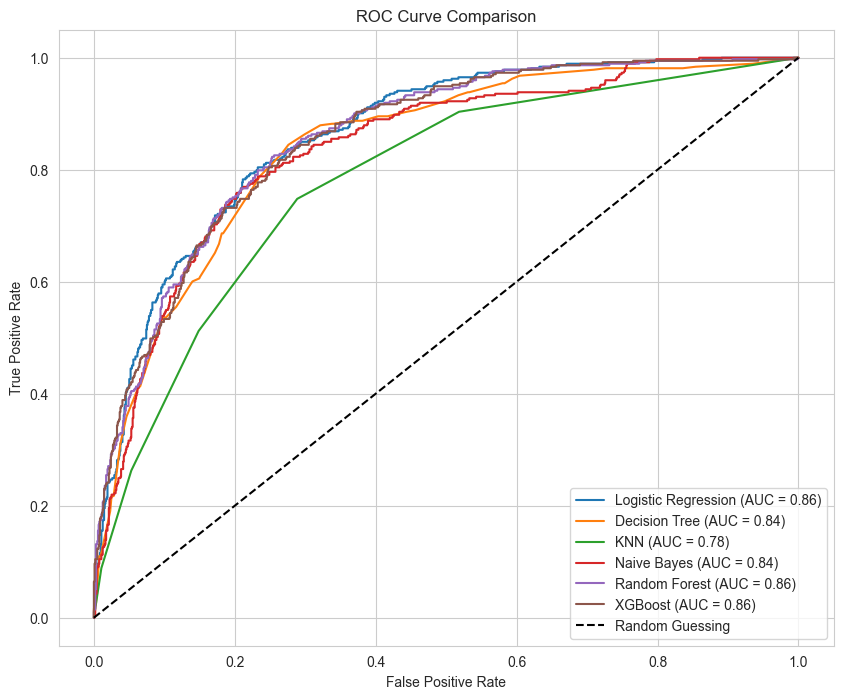

In [16]:
# Create Results DataFrame
results_df = pd.DataFrame(results_list)

# 1. Display Comparison Table
print("Model Performance Summary:")
display(results_df.round(4))

# 2. Bar Chart Comparison (Accuracy & F1)
plt.figure(figsize=(12, 6))
melted_results = pd.melt(results_df, id_vars=['ML Model Name'], value_vars=['Accuracy', 'F1 Score'], 
                         var_name='Metric', value_name='Score')
sns.barplot(x='ML Model Name', y='Score', hue='Metric', data=melted_results, palette='viridis')
plt.title('Model Comparison: Accuracy vs F1 Score')
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# 3. ROC Curves Comparison
plt.figure(figsize=(10, 8))
for name, model in models.items():
    # Get probabilities again for plotting
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()